
# Day 32 — Ensemble Learning: Voting Classifiers, Bagging & Pasting

- Understand why ensembles can outperform individual models.
- Build **hard voting** and **soft voting** classifiers.
- Understand predictor diversity and why it helps.
- Understand **bootstrap sampling**, **bagging**, and **pasting**.
- Implement bagging and pasting with scikit-learn.
- Compare ensemble performance with individual classifiers.



## 1. Ensemble intuition

An **ensemble** combines several predictors instead of relying on one predictor.

A simple intuition:

- One model may make a wrong prediction.
- If several reasonably good and somewhat different models vote independently, their errors can cancel out.
- The ensemble can therefore generalize better than many individual predictors.

A key idea is **diversity**.

If every predictor makes exactly the same mistakes, combining them provides little benefit. If their errors are less correlated, voting becomes more useful.

### Example

Suppose five classifiers predict:

`[Cat, Cat, Dog, Cat, Dog]`

Hard voting chooses:

`Cat`

The goal is not necessarily to find five perfect models. The goal is to combine models whose mistakes are not identical.



## 2. Voting classifiers

### Hard voting

For binary or multiclass classification, each classifier produces a class prediction.

The ensemble selects the class receiving the most votes.

For example:

| Model | Prediction |
|---|---|
| Logistic Regression | 1 |
| Random Forest | 1 |
| SVM | 0 |
| Decision Tree | 1 |
| KNN | 0 |

Hard vote → **1**

### Soft voting

If classifiers can estimate class probabilities, soft voting combines those probabilities and chooses the class with the highest average probability.

Soft voting often performs better when the probability estimates are reasonably calibrated.

### Important distinction

**Hard voting:** vote on predicted classes.

**Soft voting:** vote on predicted probabilities.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X, y = make_moons(n_samples=1000, noise=0.30, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((700, 2), (300, 2))

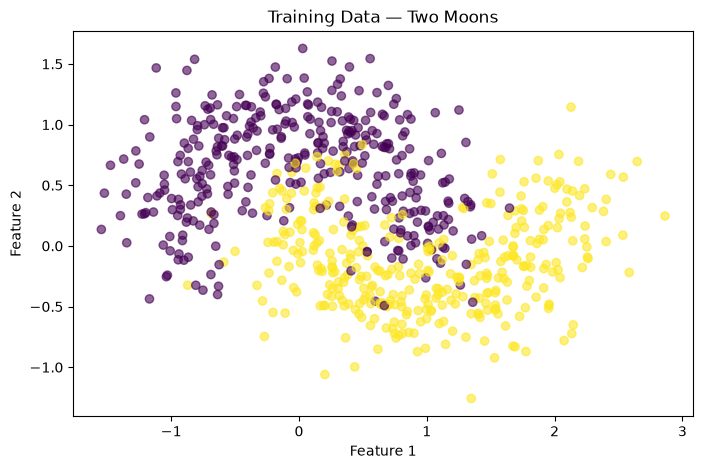

In [2]:

plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, alpha=0.6)
plt.title("Training Data — Two Moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 3. Train individual predictors

We will use three different classifiers. Different algorithms create different decision boundaries, which can provide useful diversity.

In [3]:

log_clf = LogisticRegression(random_state=42)
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
svm_clf = make_pipeline(
    StandardScaler(),
    SVC(probability=True, random_state=42)
)

classifiers = {
    "Logistic Regression": log_clf,
    "Decision Tree": tree_clf,
    "SVM": svm_clf
}

results = []

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred)
    })

pd.DataFrame(results).sort_values("Accuracy", ascending=False)


c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy
2,SVM,0.933333
1,Decision Tree,0.896667
0,Logistic Regression,0.883333



## 4. Hard voting with `VotingClassifier`

`VotingClassifier(voting="hard")` predicts the class receiving the most votes.

Conceptually:

\[
\hat y = mode(\hat y_1, \hat y_2, ..., \hat y_m)
\]

where `mode` is the majority class.


In [4]:

hard_voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(random_state=42)),
        ("tree", DecisionTreeClassifier(max_depth=5, random_state=42)),
        ("svm", make_pipeline(
            StandardScaler(),
            SVC(probability=True, random_state=42)
        ))
    ],
    voting="hard"
)

hard_voting_clf.fit(X_train, y_train)
hard_pred = hard_voting_clf.predict(X_test)

hard_accuracy = accuracy_score(y_test, hard_pred)
hard_accuracy


c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


0.9333333333333333


## 5. Soft voting

Soft voting averages the predicted probabilities:

\[
P(y=k) = \frac{1}{m}\sum_{i=1}^{m} P_i(y=k)
\]

Then the class with the largest averaged probability is selected.

In scikit-learn:

```python
VotingClassifier(..., voting="soft")
```

All classifiers used for soft voting need to provide probability estimates, directly or through a compatible configuration such as `SVC(probability=True)`.


In [5]:

soft_voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(random_state=42)),
        ("tree", DecisionTreeClassifier(max_depth=5, random_state=42)),
        ("svm", make_pipeline(
            StandardScaler(),
            SVC(probability=True, random_state=42)
        ))
    ],
    voting="soft"
)

soft_voting_clf.fit(X_train, y_train)
soft_pred = soft_voting_clf.predict(X_test)

soft_accuracy = accuracy_score(y_test, soft_pred)
soft_accuracy


c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


0.93

In [6]:

comparison = pd.DataFrame([
    ("Logistic Regression", accuracy_score(y_test, log_clf.predict(X_test))),
    ("Decision Tree", accuracy_score(y_test, tree_clf.predict(X_test))),
    ("SVM", accuracy_score(y_test, svm_clf.predict(X_test))),
    ("Hard Voting", hard_accuracy),
    ("Soft Voting", soft_accuracy),
], columns=["Model", "Accuracy"])

comparison.sort_values("Accuracy", ascending=False)


,Model,Accuracy
2,SVM,0.933333
3,Hard Voting,0.933333
4,Soft Voting,0.930000
1,Decision Tree,0.896667
0,Logistic Regression,0.883333



## 6. Why predictor diversity matters

Imagine 10 classifiers that are copies of the same model and make exactly the same mistakes.

Voting does not magically remove those mistakes.

Now imagine 10 classifiers that are individually decent but make **different** mistakes. A majority vote has a better chance of being correct.

Ways to introduce diversity include:

- using different algorithms;
- changing model hyperparameters;
- training on different subsets of the data;
- using different feature subsets;
- changing random seeds where appropriate.

This idea becomes especially important for **bagging** and **Random Forests**.



## 7. Bootstrap sampling

**Bootstrap sampling** creates a new training set by sampling **with replacement** from the original training data.

Suppose the original dataset contains:

`A B C D E`

A bootstrap sample could be:

`B D B A E`

Notice:

- `B` appears twice.
- `C` is absent.
- The sample has the same number of observations as the original dataset.
- Sampling is **with replacement**.

This creates different training sets for different predictors.


In [7]:

rng = np.random.default_rng(42)

data = np.array(["A", "B", "C", "D", "E"])

bootstrap_sample = rng.choice(
    data,
    size=len(data),
    replace=True
)

print("Original:", data)
print("Bootstrap sample:", bootstrap_sample)


Original: ['A' 'B' 'C' 'D' 'E']
Bootstrap sample: ['A' 'D' 'D' 'C' 'C']



## 8. Bagging vs. Pasting

### Bagging

**Bagging = Bootstrap Aggregating**

- Training samples are drawn **with replacement**.
- Each predictor receives a random bootstrap sample.
- Predictions are aggregated.

### Pasting

- Training samples are drawn **without replacement**.
- Each predictor receives a random subset of the training data.

| Technique | Replacement? | Typical idea |
|---|---|---|
| Pasting | No | Random subsets |
| Bagging | Yes | Bootstrap subsets |

Both are examples of ensemble methods based on training many predictors on different subsets of data.


## 9. Bagging with scikit-learn

`BaggingClassifier` can train many copies of a base estimator using randomly selected subsets of the training data.

In [8]:

from sklearn.ensemble import BaggingClassifier

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bag_clf.fit(X_train, y_train)

bag_pred = bag_clf.predict(X_test)

print("Bagging accuracy:", accuracy_score(y_test, bag_pred))


Bagging accuracy: 0.9333333333333333



### Important Bagging parameters

- `estimator`: model trained repeatedly.
- `n_estimators`: number of predictors.
- `max_samples`: number/fraction of training samples per predictor.
- `bootstrap=True`: sample with replacement → bagging.
- `bootstrap=False`: sample without replacement → pasting.
- `n_jobs=-1`: use all available CPU cores where supported.
- `random_state`: reproducibility.


## 10. Pasting with scikit-learn

In [9]:

pasting_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
    n_estimators=200,
    max_samples=0.8,
    bootstrap=False,   # without replacement = pasting
    random_state=42,
    n_jobs=-1
)

pasting_clf.fit(X_train, y_train)

pasting_pred = pasting_clf.predict(X_test)

print("Pasting accuracy:", accuracy_score(y_test, pasting_pred))


Pasting accuracy: 0.92



## 11. Compare single tree vs bagging vs pasting

The individual tree can be sensitive to the exact training set.

Bagging/pasting creates many trees trained on different subsets and aggregates their predictions.

This often reduces variance and makes the resulting model more stable.


In [10]:

tree_accuracy = accuracy_score(y_test, tree_clf.predict(X_test))
bag_accuracy = accuracy_score(y_test, bag_pred)
paste_accuracy = accuracy_score(y_test, pasting_pred)

pd.DataFrame({
    "Model": ["Single Decision Tree", "Bagging", "Pasting"],
    "Accuracy": [tree_accuracy, bag_accuracy, paste_accuracy]
}).sort_values("Accuracy", ascending=False)


,Model,Accuracy
1,Bagging,0.933333
2,Pasting,0.920000
0,Single Decision Tree,0.896667
